In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import geopandas as gpd
import zipfile
import glob
import os
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

In [ ]:
df = pd.read_csv("/content/Dataset_Kelompok5 - Dataset.csv", decimal=',')

In [ ]:
df

,Kab/Kota,Provinsi,X1,X2,X3,X4,X5,X6
0,Simeulue,Aceh,128,69.01,31944,17.69,5.50,558318
1,Aceh Singkil,NaN,107,70.75,25361,19.06,6.44,699916
2,Aceh Selatan,NaN,240,69.10,30853,12.02,4.56,623376
3,Aceh Tenggara,NaN,358,71.70,28742,11.99,4.79,655197
4,Aceh Timur,NaN,426,69.87,33666,13.26,7.75,667598
...,...,...,...,...,...,...,...,...
149,Mesuji,NaN,84,68.59,58582,6.31,2.85,631429
150,Tulang Bawang Barat,NaN,97,70.04,52209,7.22,4.12,616035
151,Pesisir Barat,NaN,94,71.04,35637,12.64,3.04,822140
152,Kota Bandar Lampung,NaN,126,80.46,65744,7.37,7.44,800857


In [ ]:
df.describe()

,X1,X2,X3,X4,X5,X6
count,154.000000,154.000000,154.000000,154.000000,154.000000,1.540000e+02
mean,148.370130,73.939870,71109.948052,9.719156,4.321169,7.496157e+05
std,119.503436,4.204639,52273.704587,4.403836,1.828330,1.272339e+05
min,13.000000,63.990000,19448.000000,2.330000,0.810000,4.343240e+05
25%,66.250000,71.175000,38773.750000,6.750000,2.860000,6.717398e+05
50%,123.000000,73.390000,56043.000000,8.740000,4.335000,7.279735e+05
75%,197.750000,76.137500,77562.500000,12.152500,5.315000,8.287740e+05
max,716.000000,87.170000,362072.000000,23.150000,9.880000,1.239790e+06


In [ ]:
# 1. Pilih hanya fitur utama (X1 hingga X6)
fitur = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
X = df[fitur].copy()

# 2. STANDARDISASI (Z-SCORE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PERHITUNGAN SILHOUETTE SCORE (Tanpa Visualisasi)
hasil_evaluasi = []
K_range = range(2, 11)

print("="*50)
print(f"{'Jumlah Klaster (K)':<25} | {'Silhouette Score'}")
print("="*50)

for k in K_range:
    # Inisialisasi dan fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_klaster = kmeans.fit_predict(X_scaled)

    # Hitung skor
    skor = silhouette_score(X_scaled, label_klaster)
    hasil_evaluasi.append({'K': k, 'Score': skor})

    # Print hasil secara real-time
    print(f"K = {k:<21} | {skor:.4f}")

print("="*50)

# 4. PENENTUAN K OPTIMAL SECARA OTOMATIS
# Mencari dictionary dengan nilai Score tertinggi
k_terbaik = max(hasil_evaluasi, key=lambda item: item['Score'])

print(f"Berdasarkan evaluasi internal algoritma, jumlah klaster optimal ")
print(f"adalah K = {k_terbaik['K']} dengan Silhouette Score tertinggi: {k_terbaik['Score']:.4f}")

Jumlah Klaster (K)        | Silhouette Score
K = 2                     | 0.2676
K = 3                     | 0.1788
K = 4                     | 0.1938
K = 5                     | 0.2040
K = 6                     | 0.1926
K = 7                     | 0.1793
K = 8                     | 0.1908
K = 9                     | 0.2030
K = 10                    | 0.1970
Berdasarkan evaluasi internal algoritma, jumlah klaster optimal 
adalah K = 2 dengan Silhouette Score tertinggi: 0.2676


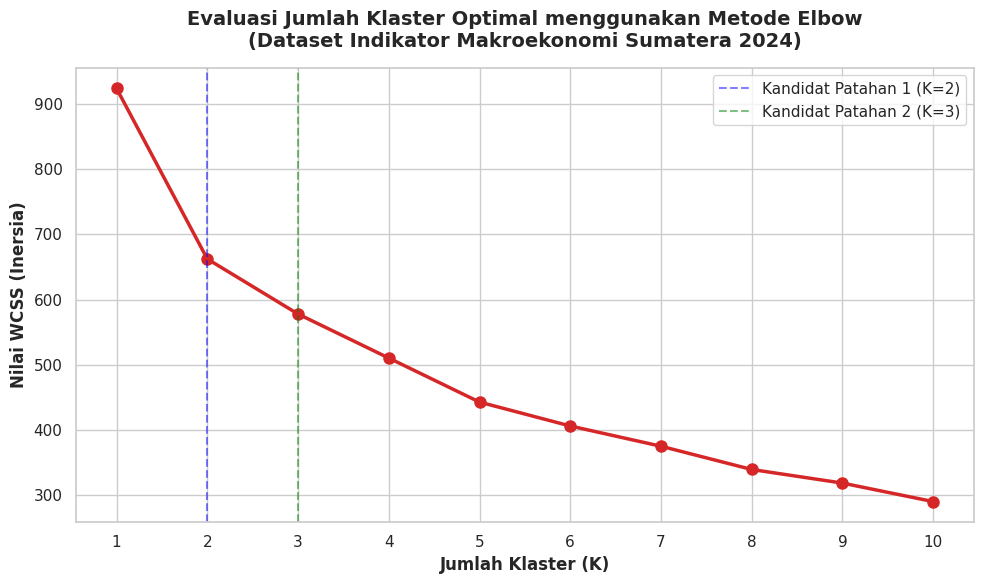

In [ ]:
# 5. KALKULASI WCSS (Within-Cluster Sum of Squares)
wcss = []
K_range = range(1, 11) # Mulai dari K=1 untuk melihat titik awal

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Inertia adalah sebutan lain untuk WCSS

# 6. VISUALISASI GRAFIK ELBOW
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot garis WCSS
plt.plot(K_range, wcss, marker='o', linestyle='-', color='#d62728', linewidth=2.5, markersize=8)

# Desain Estetika Jurnal
plt.title('Evaluasi Jumlah Klaster Optimal menggunakan Metode Elbow\n(Dataset Indikator Makroekonomi Sumatera 2024)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Klaster (K)', fontsize=12, fontweight='bold')
plt.ylabel('Nilai WCSS (Inersia)', fontsize=12, fontweight='bold')
plt.xticks(K_range)

# Tambahan garis bantu (Opsional, asumsikan patahan di K=2 atau K=3)
plt.axvline(x=2, color='blue', linestyle='--', alpha=0.5, label='Kandidat Patahan 1 (K=2)')
plt.axvline(x=3, color='green', linestyle='--', alpha=0.5, label='Kandidat Patahan 2 (K=3)')
plt.legend()

plt.tight_layout()
plt.show()

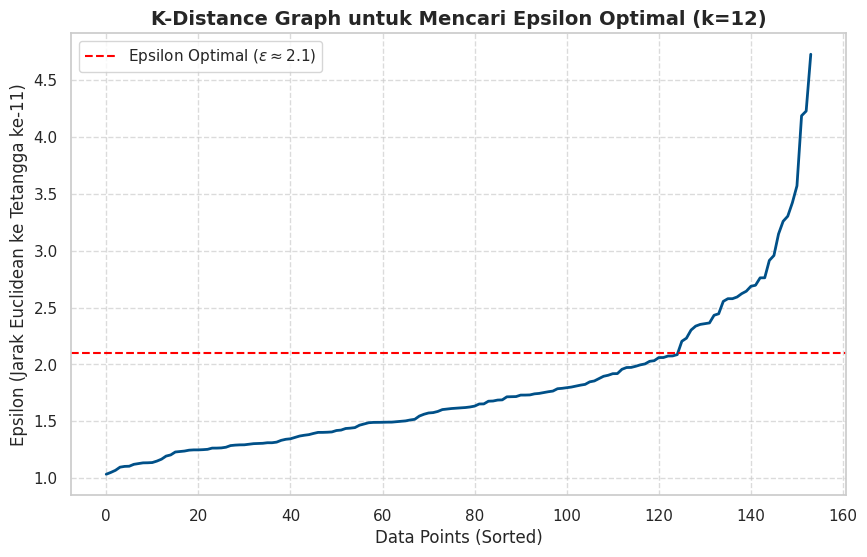

In [ ]:
k = 12

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Mengambil jarak HANYA ke tetangga yang ke-(k-1) (indeks k-1)
k_distances = distances[:, k-1]

# Urutkan jarak dari yang terkecil ke terbesar
k_distances_sorted = np.sort(k_distances, axis=0)

# Plot K-Distance Graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted, color='#005088', lw=2)
plt.title(f'K-Distance Graph untuk Mencari Epsilon Optimal (k={k})', fontsize=14, fontweight='bold')
plt.xlabel('Data Points (Sorted)', fontsize=12)
plt.ylabel(f'Epsilon (Jarak Euclidean ke Tetangga ke-{k-1})', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Tambahkan garis bantu pada epsilon yang telah dipilih
plt.axhline(y=2.1, color='red', linestyle='--', label=r'Epsilon Optimal ($\epsilon \approx 2.1$)')
plt.legend()
plt.show()

In [ ]:
df_clean = df.dropna(subset=fitur).copy()
X_clean = X.dropna()

# 7. EKSEKUSI ALGORITMA K-MEANS
# Parameter: K=2 (Berdasarkan evaluasi Silhouette Score dan Elbow Method)
kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)
label_kmeans = kmeans_model.fit_predict(X_scaled)

# Injeksi label K-Means ke dalam dataframe
df_clean['Label_KMeans'] = label_kmeans

# 8. EKSEKUSI ALGORITMA DBSCAN
# Parameter analitik berdasarkan K-Distance Graph & Rule of Thumb
dbscan_model = DBSCAN(eps=2.1, min_samples=12)
label_dbscan = dbscan_model.fit_predict(X_scaled)

# Injeksi label DBSCAN ke dalam dataframe
df_clean['Label_DBSCAN'] = label_dbscan

# 9. KOMPILASI & EKSPOR HASIL ANALITIK
# Rekapitulasi distribusi klaster
print("=== DISTRIBUSI K-MEANS ===")
print(df_clean['Label_KMeans'].value_counts().sort_index())

print("\n=== DISTRIBUSI DBSCAN ===")
# Mengubah label -1 menjadi string 'Noise'
dist_dbscan = df_clean['Label_DBSCAN'].value_counts().sort_index()
dist_dbscan.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in dist_dbscan.index]
print(dist_dbscan)

# Ekspor ke file Excel untuk analisis dan interpretasi laporan
output_filename = 'Hasil_Klasterisasi_Full.xlsx'
df_clean.to_excel(output_filename, index=False)

=== DISTRIBUSI K-MEANS ===
Label_KMeans
0    96
1    58
Name: count, dtype: int64

=== DISTRIBUSI DBSCAN ===
Noise         10
Cluster 0    144
Name: count, dtype: int64


In [ ]:
# 1. Filter hanya daerah yang dilabeli noise (-1) oleh DBSCAN
df_noise = df_clean[df_clean['Label_DBSCAN'] == -1]

# Definisikan daftar kolom lengkap untuk analisis profil multidimensi
kolom_multidimensi = ['Kab/Kota', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6']
kolom_numerik = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

# 2. EKSTRAKSI ANOMALI MAJU (Afiliasi Klaster 1 K-Means)
noise_maju = df_noise[df_noise['Label_KMeans'] == 1]
print("--- ANOMALI MAJU (K-MEANS KLASTER 1) ---")
print(noise_maju[kolom_multidimensi])

# Hitung rata-rata profil untuk melihat variabel pendorong utama anomali
print("\n[Profil Rata-Rata Anomali Maju]:")
print(noise_maju[kolom_numerik].mean().round(2))
print("-" * 60)

# 3. EKSTRAKSI ANOMALI TERTINGGAL (Afiliasi Klaster 0 K-Means)
noise_tertinggal = df_noise[df_noise['Label_KMeans'] == 0]
print("\n--- ANOMALI TERTINGGAL (K-MEANS KLASTER 0) ---")
print(noise_tertinggal[kolom_multidimensi])

# Hitung rata-rata profil untuk melihat variabel penarik utama anomali
print("\n[Profil Rata-Rata Anomali Tertinggal]:")
print(noise_tertinggal[kolom_numerik].mean().round(2))
print("-" * 60)

--- ANOMALI MAJU (K-MEANS KLASTER 1) ---
             Kab/Kota   X1     X2      X3     X4    X5       X6
14         Nagan Raya  210  71.72   70463  16.94  5.22  1120123
67      Pasaman Barat   85  70.93   46114   7.00  9.88   761925
82          Bengkalis  145  76.37  296914   6.36  5.88   911932
91  Kepulauan Anambas   50  73.47  362072   6.67  2.38   924826
92         Kota Batam   60  83.32  182507   4.85  7.68   995819

[Profil Rata-Rata Anomali Maju]:
X1       110.00
X2        75.16
X3    191614.00
X4         8.36
X5         6.21
X6    942925.00
dtype: float64
------------------------------------------------------------

--- ANOMALI TERTINGGAL (K-MEANS KLASTER 0) ---
             Kab/Kota   X1     X2      X3     X4    X5      X6
7          Aceh Besar  585  75.13   42993  13.21  7.93  729105
8               Pidie  716  72.31   32150  18.59  5.74  717855
10         Aceh Utara  695  71.70   47628  16.11  6.88  518986
36       Nias Selatan  386  65.87   23409  16.32  1.51  528794
84  Ke

In [ ]:
df_noise

,Kab/Kota,Provinsi,X1,X2,X3,X4,X5,X6,Label_KMeans,Label_DBSCAN
7,Aceh Besar,NaN,585,75.13,42993,13.21,7.93,729105,0,-1
8,Pidie,NaN,716,72.31,32150,18.59,5.74,717855,0,-1
10,Aceh Utara,NaN,695,71.70,47628,16.11,6.88,518986,0,-1
14,Nagan Raya,NaN,210,71.72,70463,16.94,5.22,1120123,1,-1
36,Nias Selatan,NaN,386,65.87,23409,16.32,1.51,528794,0,-1
67,Pasaman Barat,NaN,85,70.93,46114,7.00,9.88,761925,1,-1
82,Bengkalis,NaN,145,76.37,296914,6.36,5.88,911932,1,-1
84,Kepulauan Meranti,NaN,95,69.64,128527,23.15,4.51,680569,0,-1
91,Kepulauan Anambas,NaN,50,73.47,362072,6.67,2.38,924826,1,-1
92,Kota Batam,NaN,60,83.32,182507,4.85,7.68,995819,1,-1


In [ ]:
# 1. Filter data daerah normal (Label DBSCAN BUKAN -1)
df_inti_dbscan = df_clean[df_clean['Label_DBSCAN'] != -1]

# 2. Definisikan kolom numerik yang akan dihitung rata-ratanya
kolom_numerik = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

# 3. Hitung nilai rata-rata (mean) dan bulatkan 2 angka di belakang koma
profil_inti = df_inti_dbscan[kolom_numerik].mean().round(2)

# 4. Tampilkan hasil untuk di-copy ke Tabel VI jurnal
print("--- PROFIL RATA-RATA KLASTER INTI DBSCAN (144 DAERAH) ---")
print(profil_inti)
print("-" * 60)

# Opsional: Memastikan jumlah daerahnya benar-benar 144
print(f"Total Daerah di Klaster Inti: {len(df_inti_dbscan)} Kabupaten/Kota")

--- PROFIL RATA-RATA KLASTER INTI DBSCAN (144 DAERAH) ---
X1       137.65
X2        74.00
X3     67487.19
X4         9.50
X5         4.22
X6    746881.15
dtype: float64
------------------------------------------------------------
Total Daerah di Klaster Inti: 144 Kabupaten/Kota


<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_789/3704217147.py:57: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set_title('Distribusi Klaster: DBSCAN ($\epsilon=2.1$, MinPts=12)', fontsize=14, fontweight='bold')


Varians yang dipertahankan: PC1 = 42.31%, PC2 = 18.26%


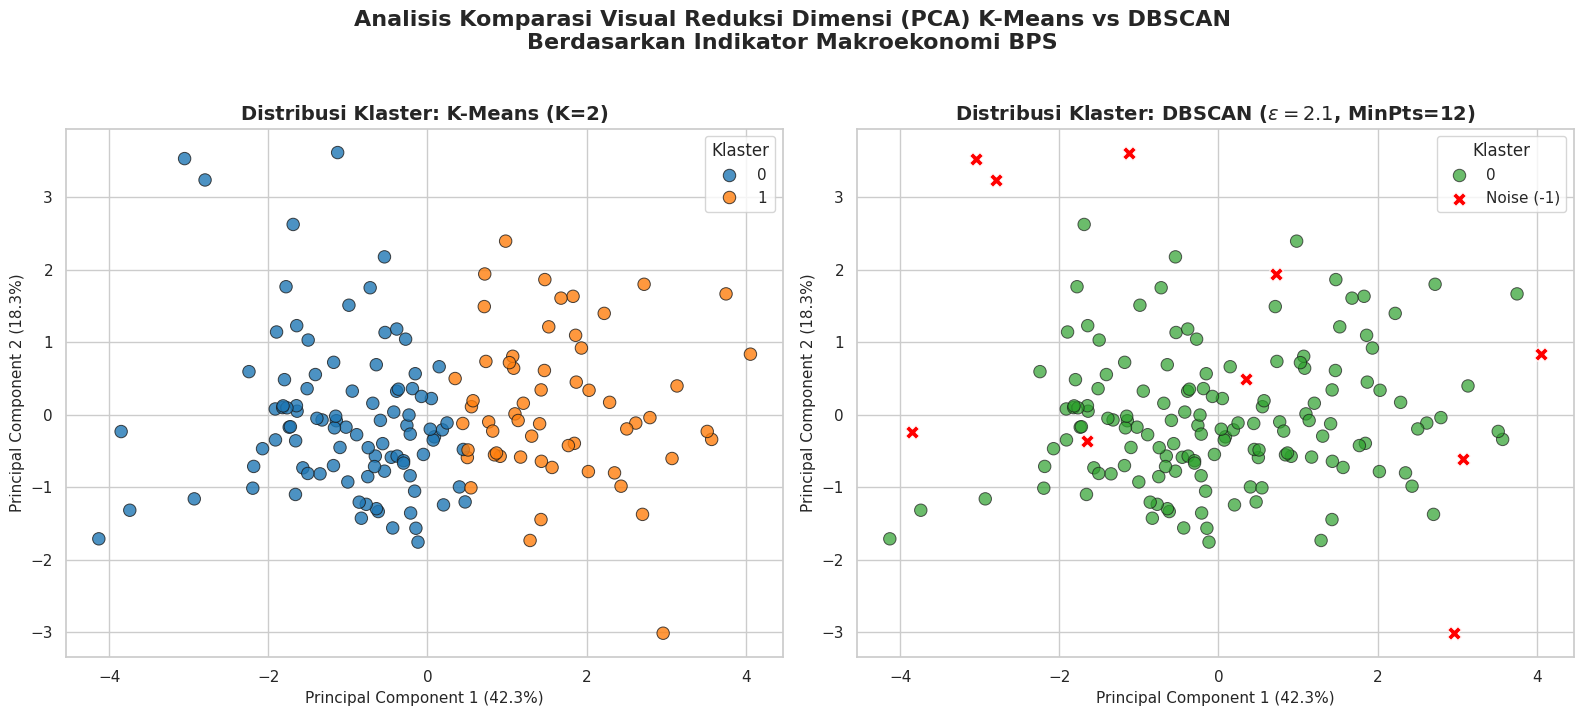

In [ ]:
# 14. REDUKSI DIMENSI DENGAN PCA (Untuk Visualisasi 2D)
# Memadatkan 6 Dimensi (X_scaled) menjadi 2 Dimensi Utama
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Menghitung rasio varians yang berhasil dipertahankan oleh PCA
var_explained = pca.explained_variance_ratio_
print(f"Varians yang dipertahankan: PC1 = {var_explained[0]*100:.2f}%, PC2 = {var_explained[1]*100:.2f}%")

# Memasukkan hasil PCA dan Label ke dalam DataFrame baru untuk plotting
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['KMeans_Label'] = df_clean['Label_KMeans'].values
df_pca['DBSCAN_Label'] = df_clean['Label_DBSCAN'].values

# 15. VISUALISASI PERBANDINGAN (SCATTER PLOT)
# Konfigurasi kanvas grafik (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

# --- GRAFIK 1: K-MEANS ---
sns.scatterplot(
    ax=axes[0],
    x='PC1', y='PC2',
    hue='KMeans_Label',
    palette=['#1f77b4', '#ff7f0e'], # Biru dan Oranye
    data=df_pca,
    s=80, alpha=0.8, edgecolor='k'
)
axes[0].set_title('Distribusi Klaster: K-Means (K=2)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}%)', fontsize=11)
axes[0].legend(title='Klaster')

# --- GRAFIK 2: DBSCAN ---
# Pisahkan data noise (-1) dan cluster valid untuk pewarnaan yang beda
noise_data = df_pca[df_pca['DBSCAN_Label'] == -1]
cluster_data = df_pca[df_pca['DBSCAN_Label'] != -1]

# Plot Cluster Valid (Misal Cluster 0)
sns.scatterplot(
    ax=axes[1],
    x='PC1', y='PC2',
    hue='DBSCAN_Label',
    palette=['#2ca02c'], # Hijau untuk Giant Component
    data=cluster_data,
    s=80, alpha=0.7, edgecolor='k'
)
# Plot Noise / Anomali (Label -1) dengan bentuk X dan warna merah
sns.scatterplot(
    ax=axes[1],
    x='PC1', y='PC2',
    color='red',
    data=noise_data,
    s=100, marker='X', label='Noise (-1)', zorder=5
)

axes[1].set_title('Distribusi Klaster: DBSCAN ($\epsilon=2.1$, MinPts=12)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}%)', fontsize=11)
axes[1].legend(title='Klaster')

# Finalisasi tata letak dan tampilkan
plt.suptitle('Analisis Komparasi Visual Reduksi Dimensi (PCA) K-Means vs DBSCAN\nBerdasarkan Indikator Makroekonomi BPS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fitur = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

# Hitung rata-rata tiap fitur per klaster
df_profile = df_clean.groupby('Label_KMeans')[fitur].mean().reset_index()

# Normalisasi min-max hanya untuk visualisasi radar
df_profile_norm = df_profile.copy()
for col in fitur:
    df_profile_norm[col] = (df_profile[col] - df_clean[col].min()) / (df_clean[col].max() - df_clean[col].min())

# Plot Radar Chart
fig_radar = go.Figure()

warna_klaster = ['#005088', '#11caa0']

for i in range(len(df_profile_norm)):
    fig_radar.add_trace(go.Scatterpolar(
        r=df_profile_norm.loc[i, fitur].values.tolist() + [df_profile_norm.loc[i, fitur].values[0]],
        theta=fitur + [fitur[0]],
        fill='toself',
        name=f'Klaster {df_profile_norm.loc[i, "Label_KMeans"]}',
        line=dict(color=warna_klaster[i % len(warna_klaster)])
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(text="Analisis Karakteristik Fitur Tiap Klaster Wilayah", font=dict(size=16, family="Arial")),
    showlegend=True
)
fig_radar.show()

In [ ]:
# 16. KODE EVALUASI KOMPARASI SINKRON DENGAN df_pca (DBSCAN METRIC FIXED)
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

labels_km = df_pca['KMeans_Label'].values
labels_db = df_pca['DBSCAN_Label'].values

# Menghitung statistik riil DBSCAN untuk informasi visual tambahan
total_noise_db = list(labels_db).count(-1)
cluster_valid_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

def hitung_performa_klaster_jurnal(X_data, labels, nama_algoritma, is_dbscan=False):
    labels_eval = labels.copy()

    cluster_aktif = len(set(labels_eval))

    if cluster_aktif < 2:
        return {
            "Algoritma": nama_algoritma, "Jumlah Cluster Evaluasi": cluster_aktif,
            "Silhouette Score": np.nan, "Davies-Bouldin Index": np.nan, "Calinski-Harabasz Index": np.nan
        }

    # Hitung metrik komparasi berdasarkan data skala asli (X_scaled)
    sil = silhouette_score(X_data, labels_eval)
    db = davies_bouldin_score(X_data, labels_eval)
    ch = calinski_harabasz_score(X_data, labels_eval)

    # jumlah cluster deskriptif yang dilaporkan di jurnal
    jml_cluster_report = f"{cluster_valid_db} (+ Noise)" if is_dbscan else f"{cluster_aktif}"

    return {
        "Algoritma": nama_algoritma,
        "Jumlah Cluster": jml_cluster_report,
        "Silhouette Score": round(sil, 4),
        "Davies-Bouldin Index": round(db, 4),
        "Calinski-Harabasz Index": round(ch, 4)
    }

# Ekstraksi performa kedua model secara objektif
eval_kmeans = hitung_performa_klaster_jurnal(X_scaled, labels_km, "K-Means (K=2)", is_dbscan=False)
eval_dbscan = hitung_performa_klaster_jurnal(X_scaled, labels_db, "DBSCAN (eps=2.1, MinPts=12)", is_dbscan=True)

# Menggabungkan hasil evaluasi ke dalam DataFrame komparasi
df_evaluasi_jurnal = pd.DataFrame([eval_kmeans, eval_dbscan])

print("="*85)
print(f"{'TABEL EVALUASI METRIK INTERNAL KOMPARASI METODE CLUSTERING':^85}")
print("="*85)
print(df_evaluasi_jurnal.to_string(index=False))
print("="*85)
print(f"Catatan Analisis: DBSCAN mendeteksi {total_noise_db} data anomali/noise (X) dari total {len(X_scaled)} daerah.")
print("="*85)
print("\n[ANALISIS PERBANDINGAN STRUKTUR KLASTER UNTUK BAB PEMBAHASAN]:")
skor_km = df_evaluasi_jurnal.iloc[0]['Silhouette Score']
skor_db = df_evaluasi_jurnal.iloc[1]['Silhouette Score']
dbi_km = df_evaluasi_jurnal.iloc[0]['Davies-Bouldin Index']
dbi_db = df_evaluasi_jurnal.iloc[1]['Davies-Bouldin Index']

print(f"1. Aspek Kepadatan (Silhouette Score): K-Means memperoleh {skor_km} sedangkan DBSCAN memperoleh {skor_db}.")
print(f"2. Aspek Pemisahan Klaster (Davies-Bouldin Index): K-Means memperoleh {dbi_km} sedangkan DBSCAN memperoleh {dbi_db}.")

if skor_km > skor_db:
    print("\n-> KESIMPULAN REKOMENDASI: K-Means (K=2) adalah metode yang LEBIH OPTIMAL untuk segmentasi wilayah.")
    print("   Alasan: K-Means menghasilkan pemisahan batas kelompok ekonomi yang lebih seimbang dan terdefinisi dengan jelas.")
    print("   DBSCAN kurang optimal untuk segmentasi merata karena struktur data makroekonomi yang dominan homogen,")
    print("   sehingga hanya menyerap seluruh wilayah ke dalam satu kelompok besar dan menyisakan pencilan.")
else:
    print("\n-> KESIMPULAN REKOMENDASI: DBSCAN lebih optimal untuk mendeteksi karakteristik lokal.")
    print("   Alasan: DBSCAN terbukti unggul dalam menyaring wilayah pencilan ekstrem yang dapat mengaburkan nilai rata-rata kelompok.")

             TABEL EVALUASI METRIK INTERNAL KOMPARASI METODE CLUSTERING              
                  Algoritma Jumlah Cluster  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
              K-Means (K=2)              2            0.2676                1.4299                  60.0178
DBSCAN (eps=2.1, MinPts=12)    1 (+ Noise)            0.3626                2.8406                   7.3380
Catatan Analisis: DBSCAN mendeteksi 10 data anomali/noise (X) dari total 154 daerah.

[ANALISIS PERBANDINGAN STRUKTUR KLASTER UNTUK BAB PEMBAHASAN]:
1. Aspek Kepadatan (Silhouette Score): K-Means memperoleh 0.2676 sedangkan DBSCAN memperoleh 0.3626.
2. Aspek Pemisahan Klaster (Davies-Bouldin Index): K-Means memperoleh 1.4299 sedangkan DBSCAN memperoleh 2.8406.

-> KESIMPULAN REKOMENDASI: DBSCAN lebih optimal untuk mendeteksi karakteristik lokal.
   Alasan: DBSCAN terbukti unggul dalam menyaring wilayah pencilan ekstrem yang dapat mengaburkan nilai rata-rata kelompok.


                      X1         X2            X3         X4        X5  \
Label_KMeans                                                             
0             188.760417  71.870833  53918.322917  11.573229  3.684375   
1              81.517241  77.364483  99565.051724   6.650345  5.375172   

                         X6  Label_DBSCAN  
Label_KMeans                               
0             685189.864583     -0.052083  
1             856251.586207     -0.086207  


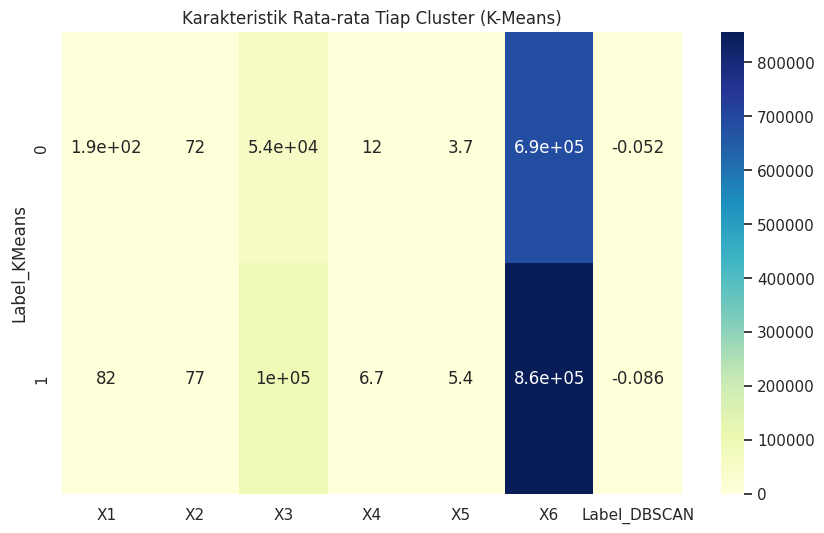

In [ ]:
# 17. KARAKTERISTIK TIAP CLUSTER
cluster_summary = df_clean.groupby('Label_KMeans').mean(numeric_only=True)
print(cluster_summary)

plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu')
plt.title('Karakteristik Rata-rata Tiap Cluster (K-Means)')
plt.show()

fatal: destination path 'indonesia-district' already exists and is not an empty directory.
Repository berhasil di-clone!

Jumlah seluruh file geojson:
7631

Jumlah file geojson Sumatera:
2123

Jumlah kabupaten/kota:
156

Kolom yang tersedia:
Index(['regency', 'geometry', 'country_code', 'country', 'province_code',
       'province', 'regency_code', 'district_code', 'district', 'village_code',
       'village', 'source', 'date', 'valid_on'],
      dtype='object')

Wilayah yang belum cocok:
[]

Jumlah wilayah berhasil merge:
156


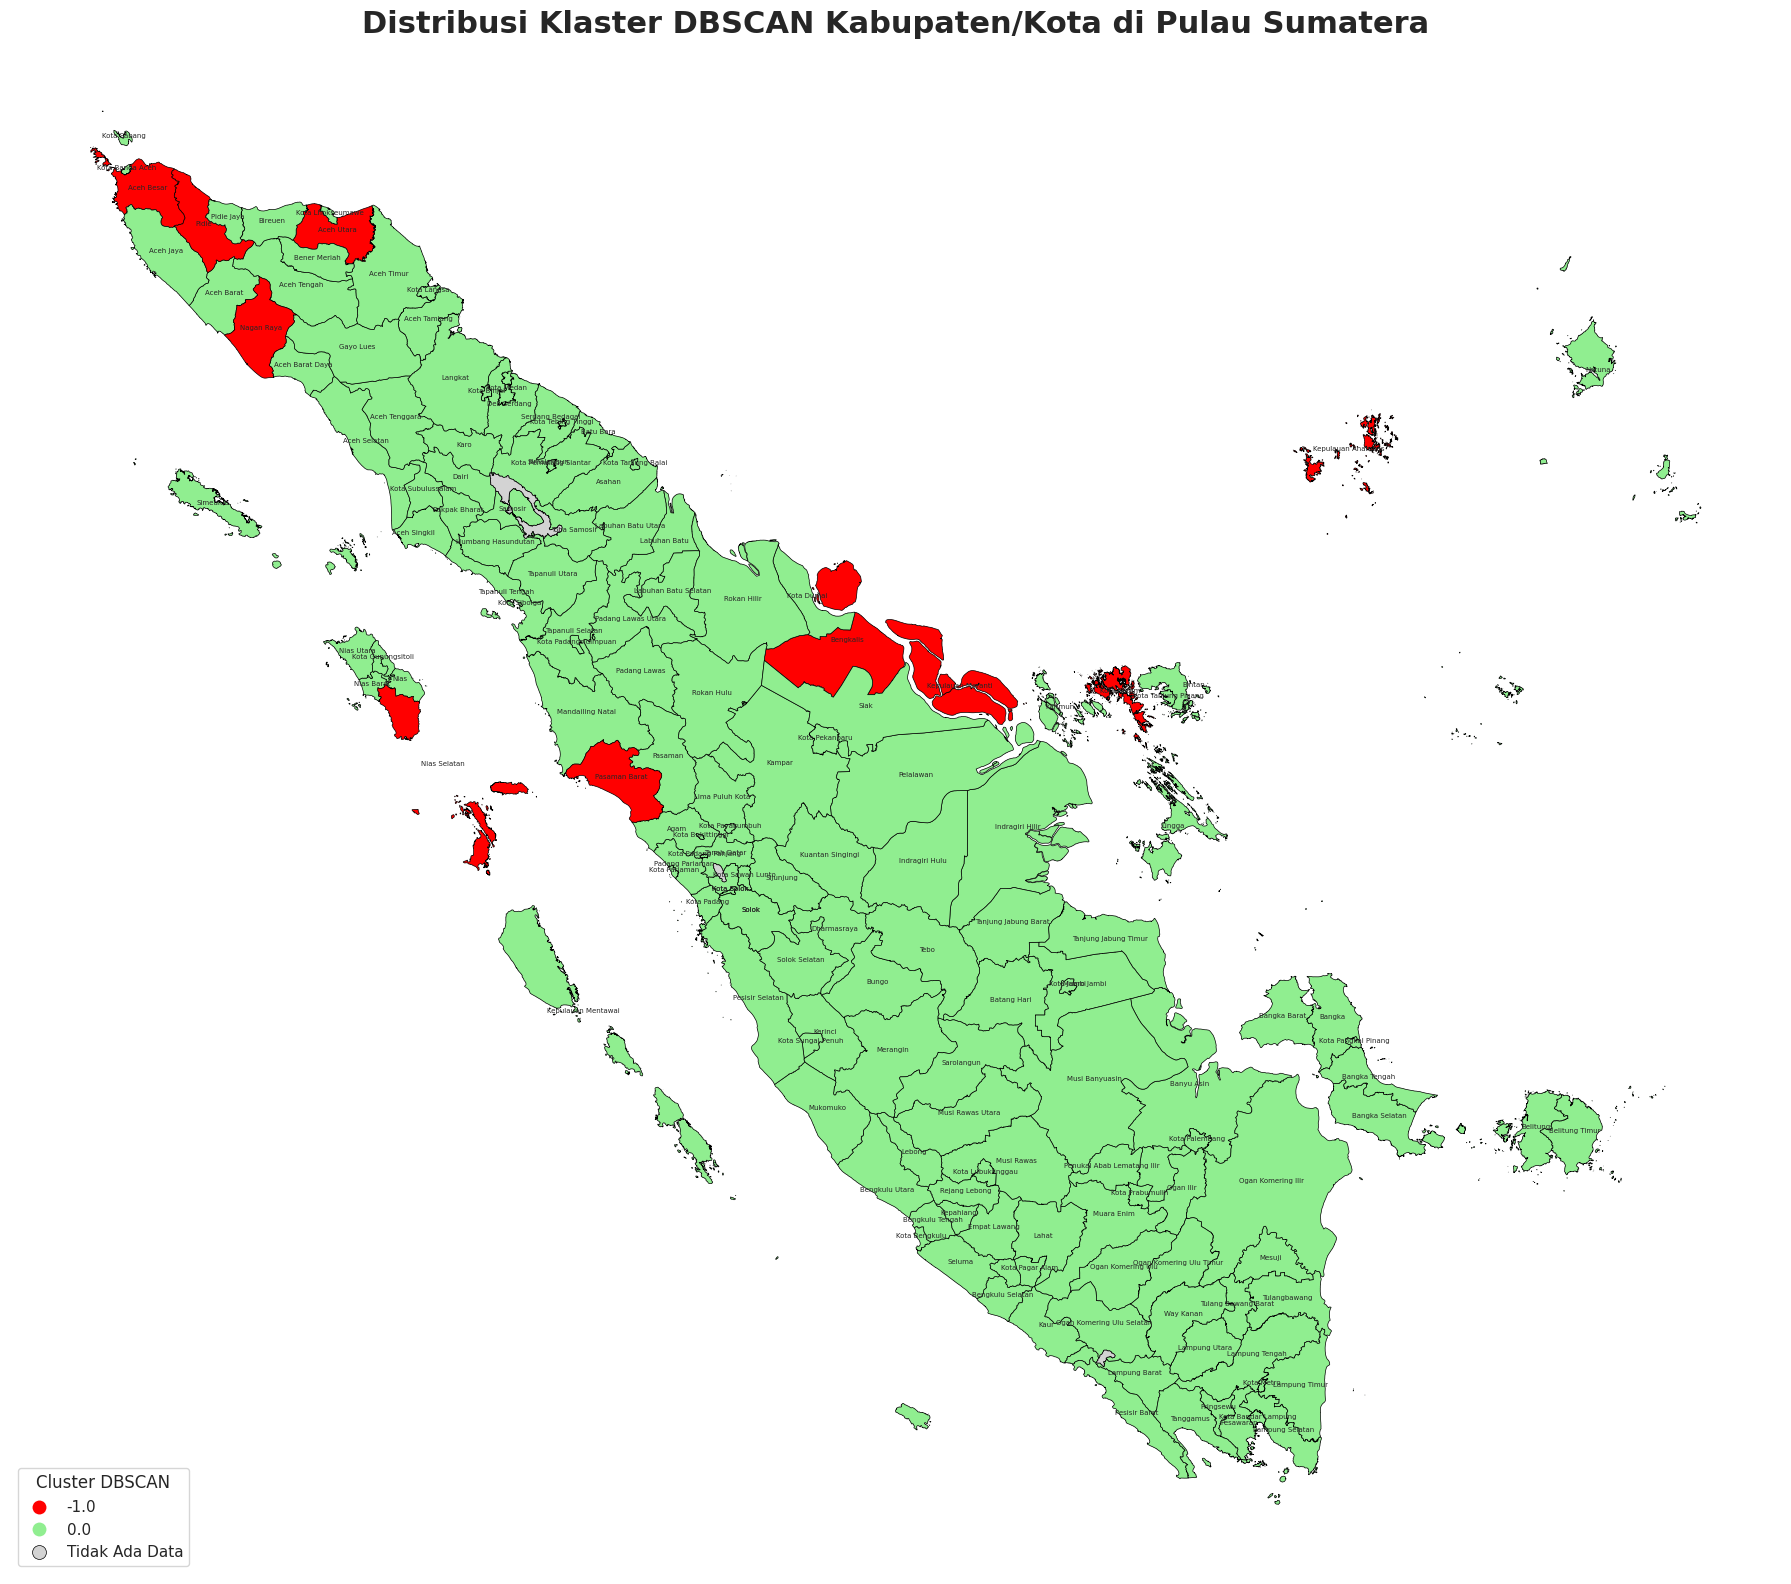

In [ ]:
from matplotlib.colors import ListedColormap
# 18. SEGMENTASI
# CLONE REPOSITORY
!git clone https://github.com/JfrAziz/indonesia-district

print("Repository berhasil di-clone!")

# CARI SEMUA FILE GEOJSON
geo_files = glob.glob(
    'indonesia-district/**/*.geojson',
    recursive=True
)

print("\nJumlah seluruh file geojson:")
print(len(geo_files))

# FILTER FILE GEOJSON SUMATERA
sumatra_codes = [
    'id11', # Aceh
    'id12', # Sumatera Utara
    'id13', # Sumatera Barat
    'id14', # Riau
    'id15', # Jambi
    'id16', # Sumatera Selatan
    'id17', # Bengkulu
    'id18', # Lampung
    'id19', # Kep. Bangka Belitung
    'id21'  # Kep. Riau
]

sumatra_files = [
    file for file in geo_files
    if any(code in file.lower() for code in sumatra_codes)
]

print("\nJumlah file geojson Sumatera:")
print(len(sumatra_files))

# LOAD & GABUNGKAN GEOJSON
gdf_list = []

for file in sumatra_files:
    gdf = gpd.read_file(file)
    gdf_list.append(gdf)

map_sumatra = pd.concat(gdf_list, ignore_index=True)

# AMBIL LEVEL KABUPATEN/KOTA SAJA
# Dissolve berdasarkan regency
map_sumatra = map_sumatra.dissolve(
    by='regency',
    as_index=False
)

# ubah jadi GeoDataFrame lagi
map_sumatra = gpd.GeoDataFrame(map_sumatra)

print("\nJumlah kabupaten/kota:")
print(len(map_sumatra))

# CEK KOLOM
print("\nKolom yang tersedia:")
print(map_sumatra.columns)

# TENTUKAN KOLOM NAMA WILAYAH
nama_kolom = 'regency'

# MEMBERSIHKAN NAMA DATASET
df_clean['KabKota_clean'] = (
    df_clean['Kab/Kota']
    .astype(str)
    .str.lower()
    .str.replace('kabupaten ', '', regex=False)
    .str.replace('kota ', '', regex=False)
    .str.replace('kab. ', '', regex=False)
    .str.replace('adm. ', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)

# MEMBERSIHKAN NAMA GEOJSON
map_sumatra['name_clean'] = (
    map_sumatra[nama_kolom]
    .astype(str)
    .str.lower()
    .str.replace('kabupaten ', '', regex=False)
    .str.replace('kota ', '', regex=False)
    .str.replace('kab. ', '', regex=False)
    .str.replace('adm. ', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)

# CEK YANG BELUM MATCH
not_match = set(df_clean['KabKota_clean']) - set(map_sumatra['name_clean'])

print("\nWilayah yang belum cocok:")
print(sorted(not_match))

# MERGE DATA
merged = map_sumatra.merge(
    df_clean,
    left_on='name_clean',
    right_on='KabKota_clean',
    how='left'
)

# CEK HASIL MERGE
print("\nJumlah wilayah berhasil merge:")
print(merged['Label_KMeans'].notna().sum())

# VISUALISASI PETA KLASTER (DBSCAN)
fig, ax = plt.subplots(figsize=(20, 16))
dbscan_cmap = ListedColormap(['red', 'lightgreen'])

merged.plot(
    column='Label_DBSCAN',
    cmap=dbscan_cmap,
    categorical=True,
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        'title': 'Cluster DBSCAN',
        'loc': 'lower left'
    },
    missing_kwds=
        {"color": "lightgray",
        "label": "Tidak Ada Data"}

)

# TAMBAHKAN NAMA KABUPATEN/KOTA
for idx, row in merged.iterrows():

    if pd.notnull(row['Label_DBSCAN']):

        point = row['geometry'].centroid

        ax.text(
            point.x,
            point.y,
            row['regency'],
            fontsize=5,
            ha='center'
        )

# JUDUL
plt.title(
    'Distribusi Klaster DBSCAN Kabupaten/Kota di Pulau Sumatera',
    fontsize=22,
    fontweight='bold'
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
# 19. TABEL HASIL KLASTER
# ambil kolom penting
hasil_cluster = merged[[
    'province',
    'regency',
    'Label_KMeans'
]].copy()

# hapus yang kosong
hasil_cluster = hasil_cluster.dropna(subset=['Label_KMeans'])

# ubah label cluster jadi integer
hasil_cluster['Label_KMeans'] = hasil_cluster['Label_KMeans'].astype(int)

# urutkan
hasil_cluster = hasil_cluster.sort_values(
    by=['Label_KMeans', 'province', 'regency']
)

# tampilkan
print(hasil_cluster)

# 20. TAMPILKAN PER CLUSTER
for cluster in sorted(hasil_cluster['Label_KMeans'].unique()):

    print("\n" + "="*60)
    print(f"CLUSTER {cluster}")
    print("="*60)

    temp = hasil_cluster[
        hasil_cluster['Label_KMeans'] == cluster
    ][['province', 'regency']]

    for provinsi in temp['province'].unique():

        print(f"\nProvinsi: {provinsi}")

        wilayah = temp[
            temp['province'] == provinsi
        ]['regency'].tolist()

        print(", ".join(wilayah))

          province               regency  Label_KMeans
0             Aceh            Aceh Barat             0
1             Aceh       Aceh Barat Daya             0
2             Aceh            Aceh Besar             0
3             Aceh             Aceh Jaya             0
4             Aceh          Aceh Selatan             0
..             ...                   ...           ...
81  Sumatera Utara    Kota Tanjung Balai             1
83  Sumatera Utara    Kota Tebing Tinggi             1
85  Sumatera Utara          Labuhan Batu             1
86  Sumatera Utara  Labuhan Batu Selatan             1
87  Sumatera Utara    Labuhan Batu Utara             1

[156 rows x 3 columns]

CLUSTER 0

Provinsi: Aceh
Aceh Barat, Aceh Barat Daya, Aceh Besar, Aceh Jaya, Aceh Selatan, Aceh Singkil, Aceh Tamiang, Aceh Tengah, Aceh Tenggara, Aceh Timur, Aceh Utara, Bener Meriah, Bireuen, Gayo Lues, Kota Subulussalam, Pidie, Pidie Jaya, Simeulue

Provinsi: Bengkulu
Bengkulu Selatan, Bengkulu Tengah, Bengkul